In [ ]:
#Y=BX+C B- BIASNESS C- COFFICENT 
#X	Y_TEST (ACTUAL)	C	Y_PRED(PREDICTION
#10	0.1         	0.1	     2
#20	0.2	            0.2	     0.2
#30	0.3	            0.3	     0.9
#40	0.4	            0.4	     0.7
#50	0.5	            0.5	     0.5

In [ ]:
X (STUDY HOURS) 	Y(P/F)	Z
4	                 0.1   0.4
5	                 0.2    1
6	                0.3	   7.2
8	                0.5	   2.4
7	                0.4	   4.2
		SUM=15.2 
		P=1/1+E^-15.2
		P=0.9999975

   Feature1  Feature2  Target
0  1.008455 -1.047010       0
1  0.326021  0.502541       1
2  1.024205 -1.797143       0
3  0.121880  1.059371       0
4  0.039100  0.382369       1

Accuracy: 0.88

Confusion Matrix
[[45  6]
 [ 6 43]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        51
           1       0.88      0.88      0.88        49

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.88      0.88      0.88       100


Predicted Class: 0
Prediction Probability: [[0.77934435 0.22065565]]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


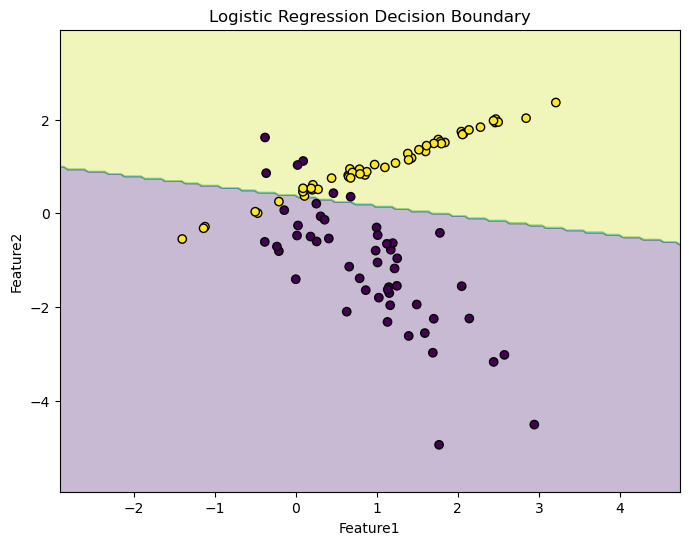

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -----------------------------
# Create Synthetic Dataset
# -----------------------------
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# Convert to DataFrame
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df["Target"] = y

# Save Dataset
df.to_csv("synthetic_logistic_dataset.csv", index=False)

print(df.head())

# -----------------------------
# Features and Target
# -----------------------------
X = df[["Feature1", "Feature2"]]
y = df["Target"]

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Train Logistic Regression
# -----------------------------
model = LogisticRegression()
model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# -----------------------------
# Predict New Data
# -----------------------------
new_data = [[1.5, -0.5]]

prediction = model.predict(new_data)
probability = model.predict_proba(new_data)

print("\nPredicted Class:", prediction[0])
print("Prediction Probability:", probability)

# -----------------------------
# Decision Boundary Plot
# -----------------------------
x_min, x_max = X.iloc[:,0].min()-1, X.iloc[:,0].max()+1
y_min, y_max = X.iloc[:,1].min()-1, X.iloc[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.05),
    np.arange(y_min, y_max, 0.05)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_test.iloc[:,0],
    X_test.iloc[:,1],
    c=y_test,
    edgecolors='k'
)

plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.title("Logistic Regression Decision Boundary")
plt.show()

In [3]:
import pickle

In [2]:
import pickle

with open("synthetic_logisticregression.pkl", "wb") as file:
    pickle.dump(model, file)

print("Saved!")

Saved!
